<a href="https://colab.research.google.com/github/prabuddhayogi/ai-with-python/blob/feature_scaling/Feature_Scaling_titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [66]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(palette="rainbow", style="darkgrid")
import time

%matplotlib inline
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
import random

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler


In [67]:
df=pd.read_csv("/content/drive/MyDrive/AI-python/lecture13/titanic_train_data.csv")
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [68]:
df_after_dropping = df.drop(columns=["SibSp", "Parch", "Ticket", "Fare", "Cabin", "Embarked"])

In [69]:
df_after_dropping.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
dtypes: float64(1), int64(3), object(2)
memory usage: 41.9+ KB


In [70]:
missing_count = df_after_dropping.isna().sum()
print(missing_count)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
dtype: int64


In [71]:
df_after_dropping["Age"] = df_after_dropping["Age"].fillna(df_after_dropping["Age"].mean())

In [72]:
missing_count_again = df_after_dropping.isna().sum()
print(missing_count_again)

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
dtype: int64


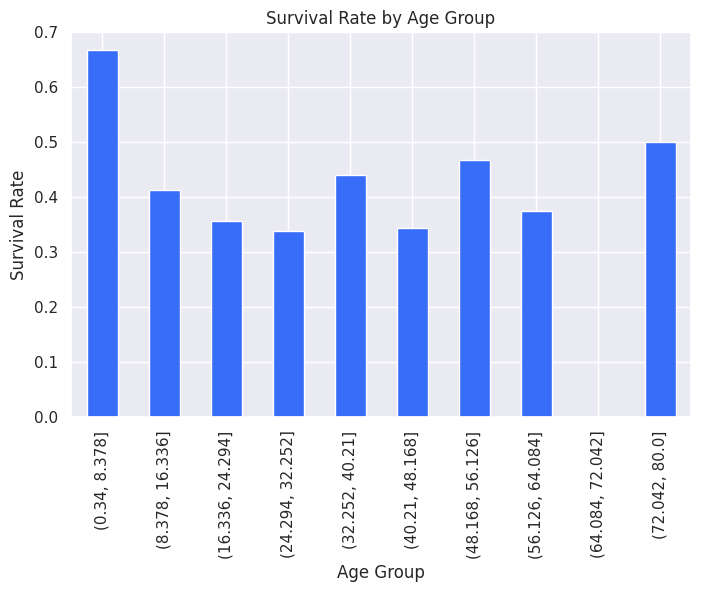

In [73]:
age_bins = pd.cut(df_after_dropping["Age"], bins=10)
survival_by_age = df_after_dropping.groupby(age_bins)["Survived"].mean()
plt.figure(figsize=(8, 5))
survival_by_age.plot(kind="bar")
plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.show()

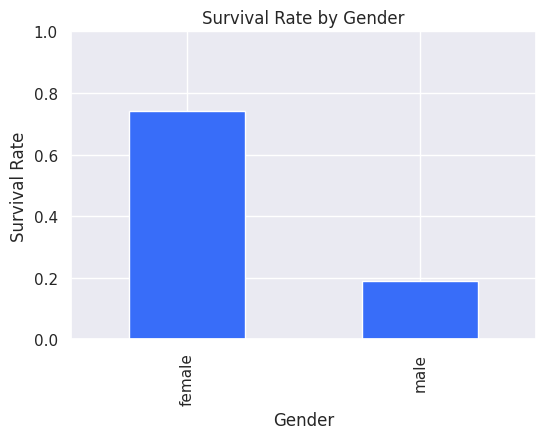

In [74]:
survival_by_gender = df_after_dropping.groupby("Sex")["Survived"].mean()
plt.figure(figsize=(6, 4))
survival_by_gender.plot(kind="bar")
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

In [75]:
X_train, X_test, Y_train, Y_test = train_test_split(
    df_after_dropping.drop('Age', axis=1),
    df_after_dropping['Age'],
    test_size=0.3,
    random_state=42
)

X_train.shape, X_test.shape

((623, 5), (268, 5))

In [76]:
scaler= StandardScaler()

scaler.fit(X_train)

X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

ValueError: could not convert string to float: 'Dodge, Master. Washington'

In [77]:
scaler.mean_

AttributeError: 'StandardScaler' object has no attribute 'mean_'

In [78]:
X_train

,PassengerId,Survived,Pclass,Name,Sex
445,446,1,1,"Dodge, Master. Washington",male
650,651,0,3,"Mitkoff, Mr. Mito",male
172,173,1,3,"Johnson, Miss. Eleanor Ileen",female
450,451,0,2,"West, Mr. Edwy Arthur",male
314,315,0,2,"Hart, Mr. Benjamin",male
...,...,...,...,...,...
106,107,1,3,"Salkjelsvik, Miss. Anna Kristine",female
270,271,0,1,"Cairns, Mr. Alexander",male
860,861,0,3,"Hansen, Mr. Claus Peter",male
435,436,1,1,"Carter, Miss. Lucile Polk",female


In [79]:
X_train_scaled

NameError: name 'X_train_scaled' is not defined

In [80]:
X_train_scaled=pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled, columns=X_test.columns)

NameError: name 'X_train_scaled' is not defined

In [81]:
X_train_scaled

NameError: name 'X_train_scaled' is not defined

In [82]:
np.round(X_train.describe(),1)

,PassengerId,Survived,Pclass
count,623.0,623.0,623.0
mean,446.6,0.4,2.3
std,260.0,0.5,0.8
min,1.0,0.0,1.0
25%,216.0,0.0,2.0
50%,454.0,0.0,3.0
75%,675.5,1.0,3.0
max,891.0,1.0,3.0


In [83]:
np.round(X_train_scaled.describe(),1)

NameError: name 'X_train_scaled' is not defined

In [84]:
print("Before Scaling - Mean Age:", X_train['Age'].mean(), "Std Dev:", X_train['Age'].std())
print("After Scaling - Mean Age:", X_train_scaled['Age'].mean(), "Std Dev:", X_train_scaled['Age'].std())


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


ax1.hist(X_train['Age'], bins=20, color='blue', alpha=0.7)
ax1.set_title('Before Scaling: Age Distribution')
ax1.set_xlabel('Age')
ax1.set_ylabel('Frequency')
ax1.grid(True)

ax2.hist(X_train_scaled['Age'], bins=20, color='red', alpha=0.7)
ax2.set_title('After Scaling: Age Distribution')
ax2.set_xlabel('Scaled Age')
ax2.set_ylabel('Frequency')
ax2.grid(True)

plt.tight_layout()
plt.show()

KeyError: 'Age'

KeyError: 'Age'

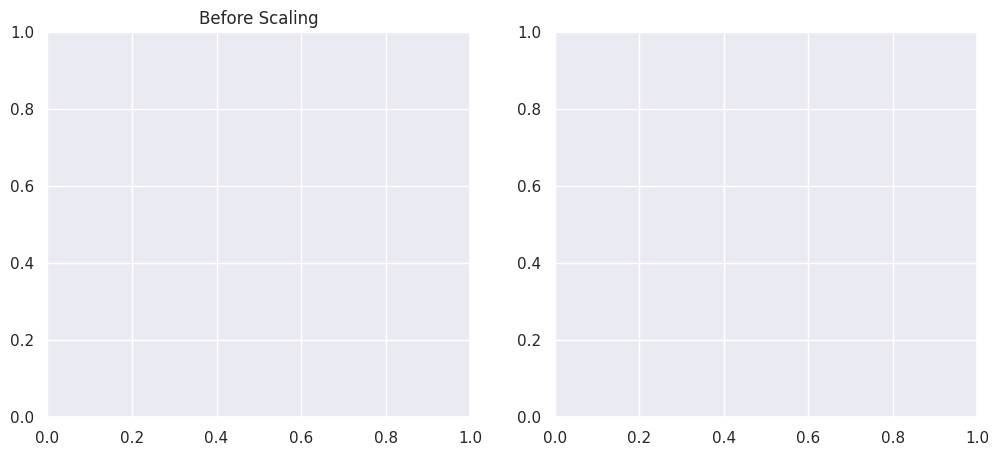

In [86]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)
sns.kdeplot(X_train['Survived'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2)
sns.kdeplot(X_train_scaled['Survived'], ax=ax2)
plt.show()

KeyError: 'Age'

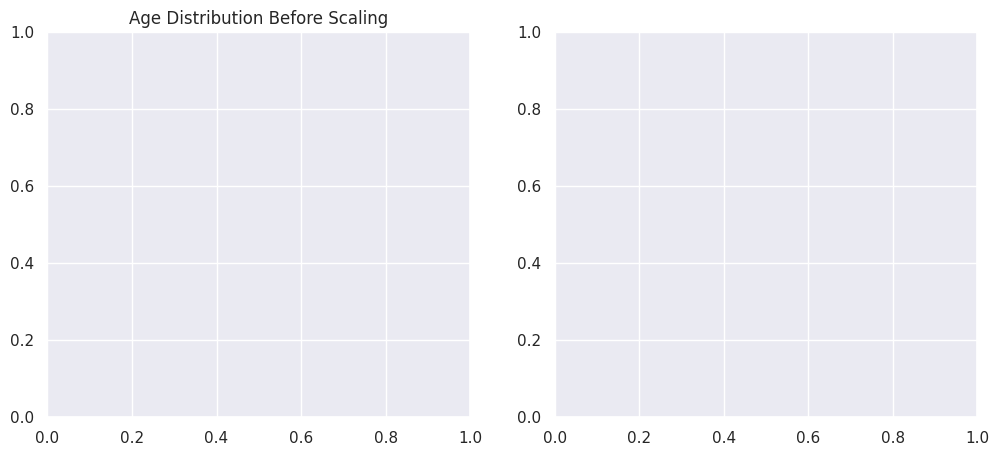

In [87]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Age Distribution Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)

# after scaling
ax2.set_title('Age Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2)
plt.show()

In [88]:
df = pd.read_csv("/content/drive/MyDrive/AI-python/lecture13/titanic_train_data.csv", usecols=["Age", "Fare"])
df["Fare"].fillna(value=df["Fare"].mean(), inplace=True)

In [89]:
df

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500
...,...,...
886,27.0,13.0000
887,19.0,30.0000
888,NaN,23.4500
889,26.0,30.0000


In [90]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
start_time = time.time()
scaled_data = scaler.fit_transform(df[['Age', 'Fare']].fillna(0))
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Time taken for MinMax scaling: {elapsed_time:.6f} seconds")

scaled_df = pd.DataFrame(scaled_data, columns=['Age', 'Fare'])

Time taken for MinMax scaling: 0.006490 seconds


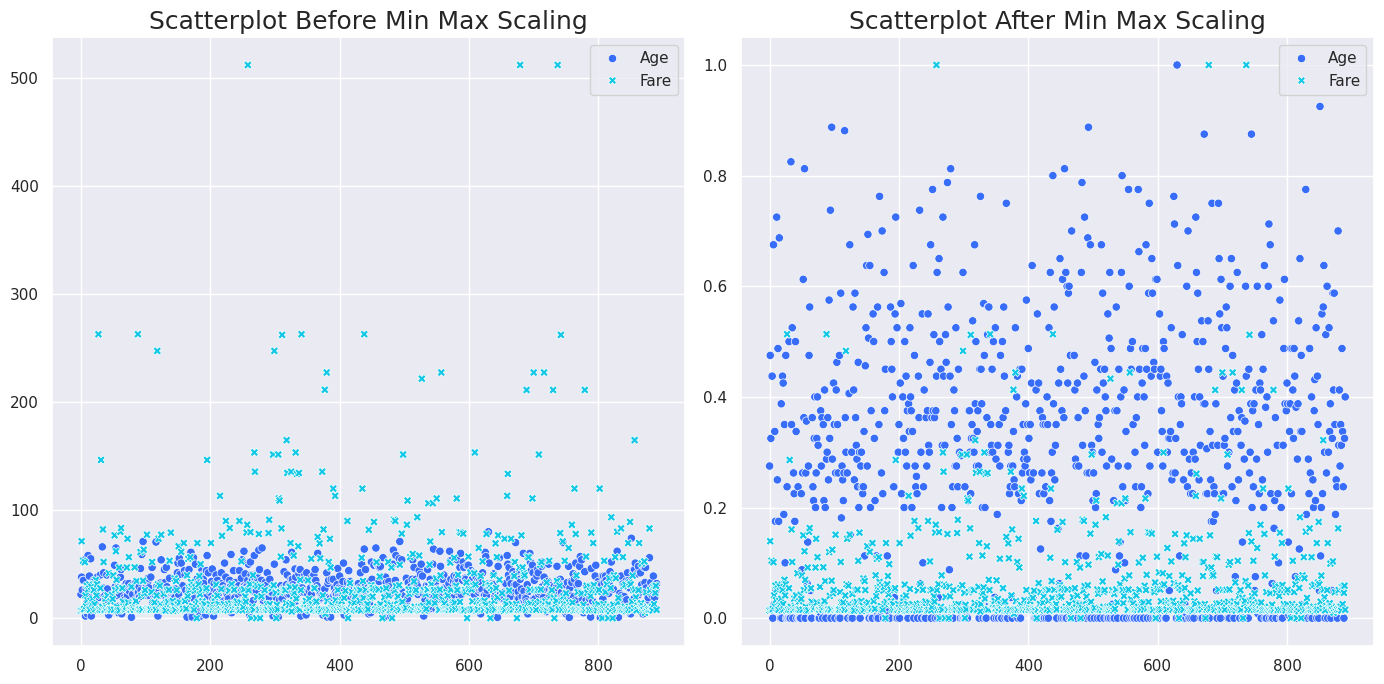

In [91]:
plt.figure(figsize=(14,7))
plt.subplot(1,2,1)
plt.title("Scatterplot Before Min Max Scaling", fontsize=18)
sns.scatterplot(data = df, color="blue")
plt.subplot(1,2,2)
plt.title("Scatterplot After Min Max Scaling", fontsize=18)
sns.scatterplot(data = scaled_df, color="red")
plt.tight_layout()
plt.show()

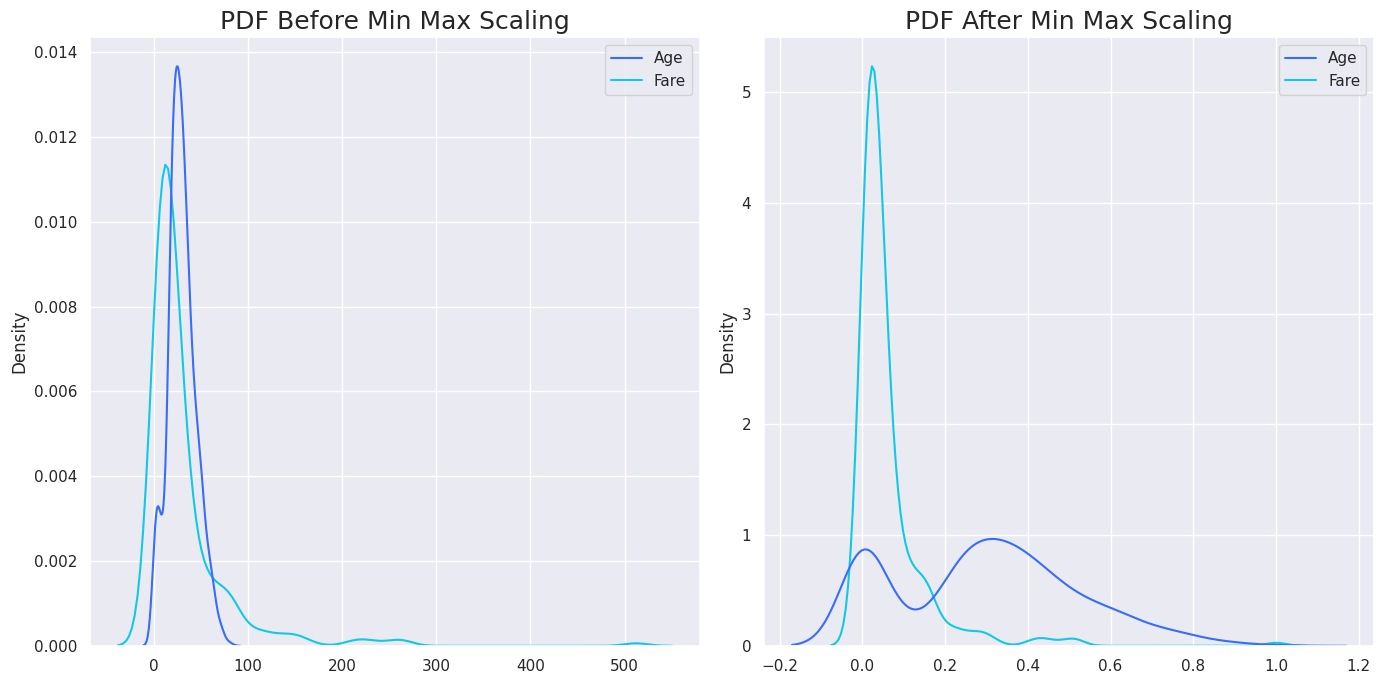

In [92]:
plt.figure(figsize=(14,7))
plt.subplot(1,2,1)
plt.title("PDF Before Min Max Scaling", fontsize=18)
sns.kdeplot(data = df, color="blue")
plt.subplot(1,2,2)
plt.title("PDF After Min Max Scaling", fontsize=18)
sns.kdeplot(data = scaled_df, color="red")
plt.tight_layout()
plt.show()

In [99]:
df = pd.read_csv("/content/drive/MyDrive/AI-python/lecture13/titanic_train_data.csv", usecols=["Age", "Survived"])
df["Age"].fillna(value=df["Age"].mean(), inplace=True)

In [100]:
df

,Survived,Age
0,0,22.000000
1,1,38.000000
2,1,26.000000
3,1,35.000000
4,0,35.000000
...,...,...
886,0,27.000000
887,1,19.000000
888,0,29.699118
889,1,26.000000


In [101]:
scaler = MinMaxScaler()
start_time = time.time()
scaled_data = scaler.fit_transform(df[['Age', 'Survived']].fillna(0))
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Time taken for MinMax scaling: {elapsed_time:.6f} seconds")

scaled_df = pd.DataFrame(scaled_data, columns=['Age', 'Survived'])

Time taken for MinMax scaling: 0.010813 seconds


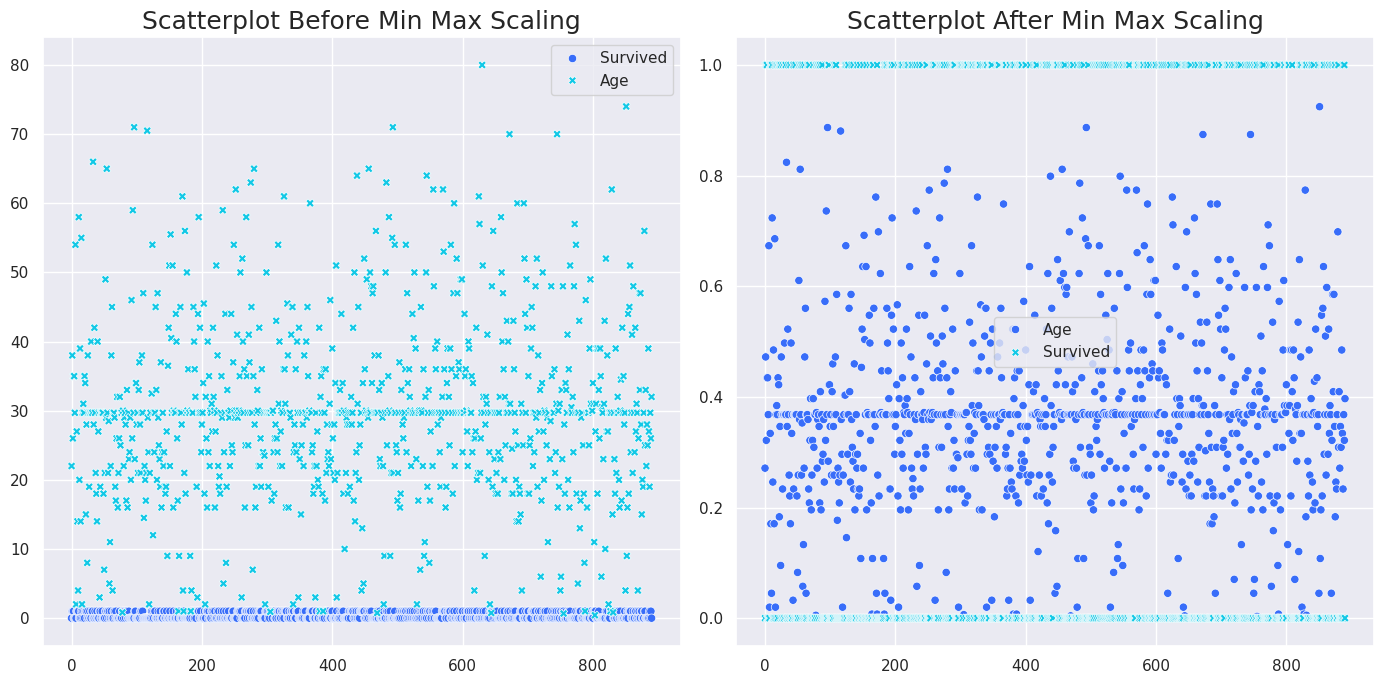

In [102]:
plt.figure(figsize=(14,7))
plt.subplot(1,2,1)
plt.title("Scatterplot Before Min Max Scaling", fontsize=18)
sns.scatterplot(data = df, color="blue")
plt.subplot(1,2,2)
plt.title("Scatterplot After Min Max Scaling", fontsize=18)
sns.scatterplot(data = scaled_df, color="red")
plt.tight_layout()
plt.show()

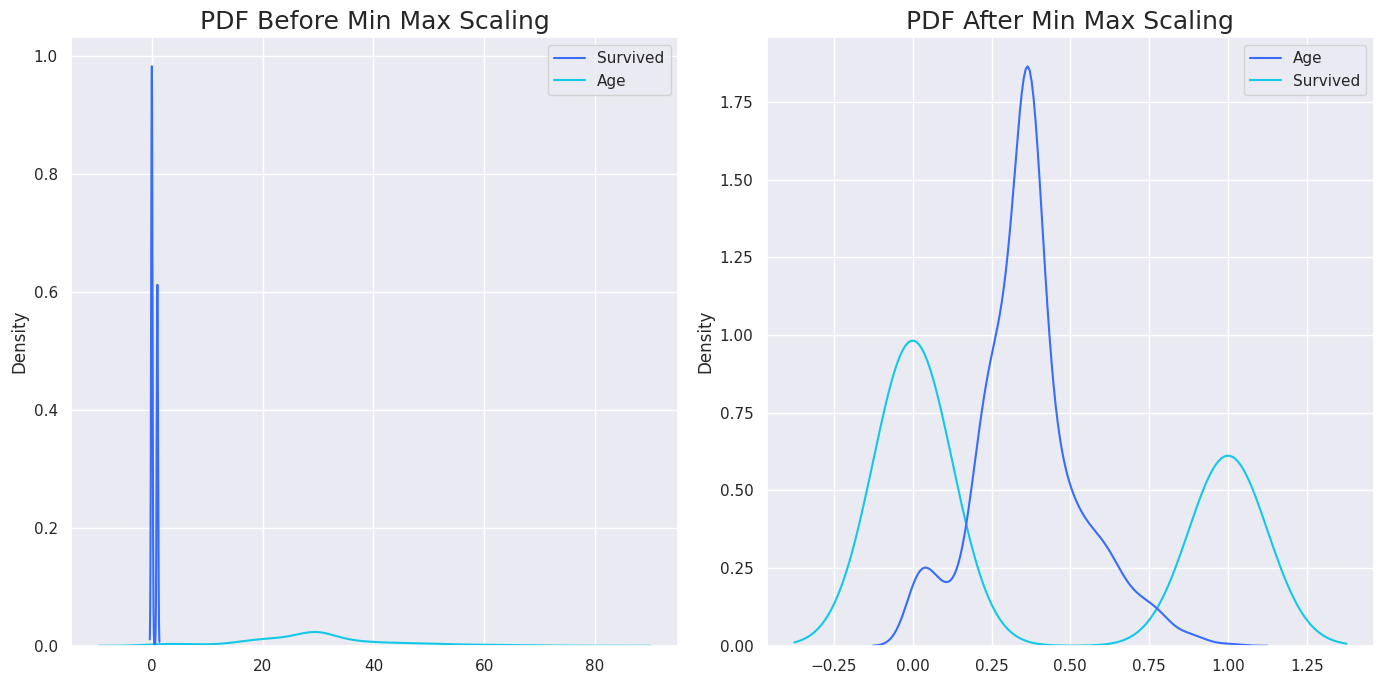

In [103]:
plt.figure(figsize=(14,7))
plt.subplot(1,2,1)
plt.title("PDF Before Min Max Scaling", fontsize=18)
sns.kdeplot(data = df, color="blue")
plt.subplot(1,2,2)
plt.title("PDF After Min Max Scaling", fontsize=18)
sns.kdeplot(data = scaled_df, color="red")
plt.tight_layout()
plt.show()